In [1]:
import duckdb
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


pl.Config(fmt_str_lengths=1000, tbl_width_chars=1000)
pl.Config(tbl_rows=10)

In [2]:
conn = duckdb.connect("amfi.duckdb")

In [3]:
# conn.execute(
#     """
# DROP VIEW IF EXISTS fund_house_v;
# DROP VIEW IF EXISTS scheme_v;
# DROP VIEW IF EXISTS scheme_document_v;
# DROP VIEW IF EXISTS scheme_aum_v;
# DROP VIEW IF EXISTS nav_plan_details_v;
# DROP VIEW IF EXISTS nav_v;
#     """
# ).pl()

In [4]:
conn.execute(
    """
    WITH nav AS (
        SELECT distinct sd_id
        FROM nav_v
    )
    SELECT np.sd_id np_sd_id, n.sd_id nav_sd_id
    FROM nav_plan_details_v np
    FULL OUTER JOIN nav n USING (sd_id)
    WHERE np.sd_id IS NULL OR n.sd_id IS NULL
    """
).pl()

np_sd_id,nav_sd_id
i32,i32


In [5]:
conn.execute(
    """
    WITH np AS (
        SELECT distinct fund_house
        FROM nav_plan_details_v
    )
    SELECT np.fund_house np_fund_house, fh.fund_house fh_fund_house
    FROM np
    FULL OUTER JOIN fund_house_v fh USING (fund_house)
    WHERE np.fund_house IS NULL OR fh.fund_house IS NULL
    """
).pl()

np_fund_house,fh_fund_house
str,str


In [47]:
conn.execute(
    """
    WITH plans AS (
        SELECT sd_id, plan, scheme
            , NOT regexp_matches(
                plan, '(?i)(unclaimed|bonus option|provident fund|wholesale|bonus)'
            ) AS is_retail
            , (
                plan ILIKE '%no lock in%'
                OR NOT EXISTS (
                    SELECT 1
                    FROM nav_plan_details_v p2
                    WHERE p2.scheme = npd.scheme
                    AND p2.plan ILIKE '%no lock in%'
                )
            ) AS is_not_lockin
            , plan ILIKE '%growth%' AND plan NOT ILIKE '%growth%fund%' is_growth
            , plan ILIKE '%direct%' AND plan NOT ILIKE '%indirect%' is_direct
        FROM nav_plan_details_v npd
    ),
    agg AS (
        SELECT COUNT(*) AS plans
            , SUM(is_retail AND is_not_lockin) AS retail
            , SUM(is_retail AND is_not_lockin AND is_growth) AS growth
            , SUM(is_retail AND is_not_lockin AND is_growth AND is_direct) AS direct_growth
        FROM plans
    ),
    grp AS (
        SELECT scheme, string_agg(plan)
        FROM plans
        WHERE is_retail AND is_not_lockin AND is_growth AND is_direct
        GROUP BY scheme HAVING count(*) <> 1
    )
    SELECT *
    FROM grp
    """
).pl()

scheme,string_agg(plan)
str,str
"""UTI - Healthcare Fund""","""UTI Services Industries Fund-Growth Option- Direct,UTI Energy Fund-Growth Option-Direct,UTI Healthcare Fund - Direct Plan - Growth Option"""
"""Franklin India Government Securities Fund""","""Franklin India GOVERNMENT SECURITIES FUND - Composite Plan - Direct - Growth,Franklin India Government Securities Fund - Direct - Growth,Franklin India GOVERNMENT SECURITIES FUND TREASURY PLAN - Direct - Growth,Franklin India GOVERNMENT SECURITIES FUND PF PLAN - Direct - Growth"""
"""Baroda Treasury Advantage Fund""","""Baroda Treasury Advantage Fund - Plan B (Direct) - Growth Option,Baroda Treasury Advantage Fund-Plan B (Direct)- Growth Option- Segregated Portfolio-1"""
"""Nippon India Conservative Hybrid Fund (Existing number of Segregated Portfolios - 1)""","""Nippon India Conservative Hybrid Fund - Direct Plan Growth Plan - Growth Option,Nippon India Conservative Hybrid Fund - Segregated Portfolio 2 - Direct Plan - Growth Plan - Growth Option,Nippon India Conservative Hybrid Fund - Segregated Portfolio 1 - Direct Plan Growth Plan - Growth Option"""
"""Sundaram Low Duration Fund""","""Sundaram Low Duration Fund Direct Plan - Growth,Sundaram Low Duration Fund Direct Plan -Growth"""
…,…
"""Nippon India Equity Savings Fund (Existing number of Segregated Portfolios - 2)""","""Nippon India Equity Savings Fund - Segregated Portfolio 1 - Direct Plan - Growth Plan - Growth Option,Nippon India Equity Savings Fund- Direct Plan- Growth Plan-Growth Option,Nippon India Equity Savings Fund - Segregated Portfolio 2 - Direct Plan - Growth Plan - Growth Option"""
"""Nippon India Liquid Fund""","""Nippon India Liquid Fund - Direct Plan Growth Plan - Growth Option,Reliance Liquid Fund - Cash Plan - Direct Plan - Growth Plan - Growth Option"""
"""Sundaram Medium Duration Fund (Formerly Known as Sundaram Medium Term Bond Fund)""","""Sundaram Medium Duration Fund (Formerly Known as Sundaram Medium Term Bond Fund Direct Plan -Growth,Sundaram Medium Duration Fund (Formerly Known as Sundaram Medium Term Bond Fund) Direct Plan - Growth"""


In [10]:
conn.execute(
    """
    SELECT 'RAW_NAV', count(*) count FROM raw_nav
    UNION ALL
    SELECT 'RAW_FUND_DETAILS', count(*) count FROM raw_fund_details
    UNION ALL
    SELECT 'DATE_RUN', count(*) count FROM date_run
    UNION ALL
    SELECT 'PLANS', count(*) count FROM plans
    UNION ALL
    SELECT 'ACTIVE_PLANS', count(*) count FROM active_plans
    """
).pl()

CatalogException: Catalog Error: Table with name raw_fund_details does not exist!
Did you mean "raw_fund_house"?

LINE 4:     SELECT 'RAW_FUND_DETAILS', count(*) count FROM raw_fund_details
                                                           ^

In [63]:
conn.execute(
    """
    CREATE OR REPLACE TABLE plans_active AS
    WITH plans AS (
        SELECT fund_house, scheme, plan, sd_id
            , NOT regexp_matches(scheme, '(?i)(deactivate|closed 1|closed|not to use)') is_no_use
            , NOT regexp_matches(
                plan, '(?i)(unclaimed|bonus option|provident fund|wholesale|bonus)'
            ) AS is_retail
            , (
                plan ILIKE '%no lock in%'
                OR NOT EXISTS (
                    SELECT 1
                    FROM nav_plan_details_v p2
                    WHERE p2.scheme = npd.scheme
                    AND p2.plan ILIKE '%no lock in%'
                )
            ) AS is_not_lockin
            , plan ILIKE '%growth%' AND plan NOT ILIKE '%growth%fund%' is_growth
            , plan ILIKE '%direct%' AND plan NOT ILIKE '%indirect%' is_direct
        FROM nav_plan_details_v npd
    ),
    nav AS (
        SELECT sd_id, min(date) start_date, max(date) latest_date
        from nav_v
        GROUP BY sd_id
    )
    SELECT fh.fund_house_id, fh.fund_house
        , sc.scheme_id, sc.scheme
        , p.sd_id, plan
        , sc.scheme_type , sc.scheme_category, sa.aum
        , sc.launch_date, n.start_date, n.latest_date
        , p.is_no_use, p.is_retail, p.is_not_lockin, p.is_growth, p.is_direct
    FROM plans p
    INNER JOIN nav n USING (sd_id)
    INNER JOIN fund_house_v fh USING (fund_house)
    LEFT JOIN scheme_v sc USING (scheme)
    LEFT JOIN scheme_aum_v sa USING (plan)
    WHERE TRUE
        AND latest_date > current_date - 10
    """
).pl()

Count
i64
8708


In [66]:
# Deactivated Funds
conn.execute(
    """
    CREATE OR REPLACE TABLE nav_active AS
    SELECT sd_id, date, nav
    FROM nav_v
    WHERE sd_id IN (SELECT sd_id FROM plans)
        AND nav > 0
    """
).pl()

Success
bool


In [64]:
# Deactivated Funds
conn.execute(
    """
    """
).pl()

Count
i64
16282987


In [72]:
conn.execute(
    """
    CREATE OR REPLACE TABLE nav AS
    WITH config AS (
        -- Define your threshold here once. 0.25 (25%) will catch the 30% drop.
        SELECT 0.25 AS outlier_threshold 
    ),
    nav_context AS (
        SELECT 
            sd_id, date, nav,
            LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS prev_nav,
            LEAD(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS next_nav
        FROM nav_active
    ),
    de_blipped AS (
        SELECT 
            c.sd_id, c.date, c.nav AS raw_nav,
            CASE 
                WHEN c.prev_nav IS NOT NULL AND c.next_nav IS NOT NULL 
                 -- Reference the config threshold
                 AND ABS((c.nav / c.prev_nav) - 1) > (SELECT outlier_threshold FROM config)
                 AND ABS((c.next_nav / c.prev_nav) - 1) < 0.10 
                THEN (c.prev_nav + c.next_nav) / 2.0
                ELSE c.nav
            END AS clean_nav
        FROM nav_context c
    ),
    split_detection AS (
        SELECT 
            sd_id, date, raw_nav, clean_nav,
            LAG(clean_nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS prev_clean_nav
        FROM de_blipped
    ),
    split_factors AS (
        SELECT 
            sd_id, date, raw_nav, clean_nav,
            CASE
                WHEN prev_clean_nav IS NULL THEN 1.0
                -- Reference the config threshold
                WHEN ABS((clean_nav / prev_clean_nav) - 1) > (SELECT outlier_threshold FROM config) 
                THEN (clean_nav / prev_clean_nav)
                ELSE 1.0
            END AS daily_factor
        FROM split_detection
    ),
    cumulative_splits AS (
        -- Stage 2.3: Calculate the running product of split factors
        SELECT 
            sd_id,
            date,
            raw_nav,
            clean_nav,
            daily_factor,
            EXP(SUM(LN(daily_factor)) OVER (PARTITION BY sd_id ORDER BY date ASC)) AS running_factor
        FROM split_factors
    ),
    terminal_splits AS (
        -- Stage 2.4: Extract the final cumulative factor to anchor the series
        SELECT 
            sd_id,
            arg_max(running_factor, date) AS terminal_factor
        FROM cumulative_splits
        GROUP BY sd_id
    )
    -- Final Output: Scale historical prices
    SELECT 
        c.sd_id, c.date,
        -- Formula: Current scale / Point-in-time scale
        c.clean_nav * (t.terminal_factor / c.running_factor) AS nav,
        c.raw_nav
    FROM cumulative_splits c
    JOIN terminal_splits t ON c.sd_id = t.sd_id
    ORDER BY c.sd_id, c.date;
    """
).pl()

Count
i64
16282987


In [8]:
# Deactivated Funds
# conn.execute(
#     """
#     with nav AS (
#         SELECT
#             sd_id,
#             nav,
#             date
#         FROM clean_nav
#         QUALIFY ROW_NUMBER() OVER (
#             PARTITION BY sd_id, date
#             ORDER BY loaded_at DESC
#         ) = 1
#     )
#     SELECT nav.*
#     FROM nav
#     INNER JOIN plans
#     ON nav.sd_id = plans.sd_id
#     WHERE plans.infer_active
#     LIMIT 10
#     """
# ).pl()

In [9]:
conn.execute(
    """
    SELECT count(*)
        , count(DISTINCT CASE WHEN start_date <= '2020-01-01' THEN scheme_id END) schemes_2020
        , count(DISTINCT CASE WHEN start_date <= '2015-01-01' THEN scheme_id END) schemes_2015
    FROM active_plans
    """
).pl()

count_star(),schemes_2020,schemes_2015
i64,i64,i64
731,731,503


In [267]:
conn.execute(
    """
    SELECT *
    FROM plans
    WHERE sd_id = 119118
    """
).pl()

scheme_id,scheme,sd_id,plan,start_date,latest_date,latest_nav,day_count
i64,str,i32,str,date,date,"decimal[18,6]",i64
2502,"""HDFC Hybrid Debt Fund""",119118,"""HDFC Hybrid Debt Fund - Growth Option - Direct Plan""",2013-01-01,2026-03-25,87.343500,3196


In [10]:
conn.execute(
    """
    SELECT sd_id, COUNT(DISTINCT scheme_id) count
    FROM nav
    WHERE sd_id in (SELECT sd_id from active_plans)
    GROUP BY sd_id HAVING COUNT(DISTINCT scheme_id) <> 1
    ORDER BY count DESC
    """
).pl().show(100)

sd_id,count
i32,i64


In [207]:
conn.execute(
    """
    CREATE OR REPLACE VIEW active_nav AS
    SELECT sd_id, date, nav
    FROM nav
    WHERE sd_id in (SELECT sd_id from active_plans)
        AND date >= '2015-01-01'
    ORDER BY scheme_id, sd_id, date
    """
).pl()

Count
i64


In [265]:
conn.execute(
    """
    WITH raw AS (
        SELECT sd_id, (nav / LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC)) - 1 return
        FROM active_nav
    ),
    agg AS (
        SELECT raw.sd_id, plan, ROUND(AVG(CASE WHEN return >= 0 THEN 1 ELSE 0 END), 2) win_pct
        FROM raw
        LEFT JOIN plans USING (sd_id)
        WHERE TRUE
            AND plan ILIKE '%debt%'
        GROUP BY sd_id, plan HAVING count(*) > 100
    )
    SELECT win_pct, count(*), string_agg(sd_id)
    FROM agg
    GROUP BY win_pct
    ORDER BY win_pct
    """
).pl().show(100)

win_pct,count_star(),string_agg(sd_id)
f64,i64,str
0.57,2,"""120251,119635"""
0.58,1,"""119118"""
0.59,1,"""120154"""
0.6,1,"""139527"""
0.61,1,"""136465"""
0.63,1,"""119075"""
0.67,2,"""140286,146943"""
0.69,1,"""146727"""
0.71,1,"""124175"""


In [208]:
# Funds which get 0 randomly inbetween
conn.execute(
    """
    WITH first_positive AS (
        -- Identify the start of the valid series for each sd_id
        SELECT sd_id, min(date) AS start_date
        FROM active_nav
        WHERE nav > 0
        GROUP BY sd_id
    )
    SELECT
        a.sd_id,
        f.start_date AS first_non_zero_date,
        count(CASE WHEN a.nav <= 0 THEN 1 END) AS count_non_positive_after_start,
        string_agg(
            CASE WHEN a.nav <= 0 THEN a.date::VARCHAR END, 
            ', ' ORDER BY a.date
        ) AS non_positive_dates
    FROM active_nav a
    JOIN first_positive f 
        ON a.sd_id = f.sd_id
    WHERE a.date > f.start_date
    GROUP BY a.sd_id, f.start_date HAVING count_non_positive_after_start > 0;
    """
).pl().show(100)

sd_id,first_non_zero_date,count_non_positive_after_start,non_positive_dates
i32,date,i64,str


In [76]:
conn.execute(
    """
    WITH lagged_data AS (
        SELECT 
            sd_id, date, nav,
            LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) as prev_nav
            , CASE 
                WHEN prev_nav = 0 THEN NULL 
                ELSE (nav / prev_nav) - 1 
            END AS simple_return
        FROM nav
    )
    SELECT 
        scheme, sd_id
        , max(simple_return) max_ret, arg_max(date, simple_return) max_date
        , min(simple_return) min_ret, arg_min(date, simple_return) min_date
        , sum(CASE WHEN simple_return > 0.36 THEN 1 END) high_osc
        , sum(CASE WHEN simple_return < -0.36 THEN 1 END) low_osc
        , QUANTILE_CONT(simple_return, 0.95) pct_95
        , QUANTILE_CONT(simple_return, 0.05) pct_05
    FROM lagged_data
    LEFT JOIN plans ap USING (sd_id) 
    GROUP BY scheme, sd_id HAVING max_ret > 0.36 OR min_ret < -0.36
    ORDER BY max_ret DESC;
    """
).pl().show(200)

scheme,sd_id,max_ret,max_date,min_ret,min_date,high_osc,low_osc,pct_95,pct_05
str,i32,f64,date,f64,date,"decimal[38,0]","decimal[38,0]",f64,f64


In [211]:
conn.execute(
    """
    SELECT *
    FROM adjusted_nav
    WHERE sd_id = 138358
    and date >= '2019-09-05' and date <= '2019-09-20'
    """
).pl().show(1000)

sd_id,date,raw_nav,nav
i32,date,"decimal[18,6]",f64
138358,2019-09-05,24.9308,25.059693
138358,2019-09-06,24.955,25.084018
138358,2019-09-09,25.0276,25.156993
138358,2019-09-11,25.0759,25.205543
138358,2019-09-12,25.1003,25.230069
138358,2019-09-13,17.4969,25.230069
138358,2019-09-16,17.5402,25.292506
138358,2019-09-17,17.5403,25.292651
138358,2019-09-18,17.5422,25.29539


In [78]:
conn.execute(
    """
    SELECT *
    FROM plans
    WHERE TRUE
        AND sd_id in (
            147606
        )
        --AND scheme ILIKE '%NIFTY 50%'
    """
).pl()

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,scheme_category,aum,launch_date,start_date,latest_date,is_no_use,is_retail,is_not_lockin,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,f64,date,date,date,bool,bool,bool,bool,bool
58,"""PGIM India Mutual Fund""",12012,"""PGIM India Overnight Fund""",147606,"""PGIM India Overnight Fund - Direct Plan - Growth Option""","""Open Ended""","""Debt Scheme - Overnight Fund""",6945.85,2019-08-12,2019-08-28,2026-03-26,true,true,true,true,true


In [220]:
conn.execute(
    """
    WITH weekly AS (
        SELECT sd_id
            , (date_trunc('week', date) + INTERVAL '4 days')::date AS week_end_date
            , arg_max(nav, date) AS week_nav
            , lag(week_nav) OVER (PARTITION BY sd_id ORDER BY week_end_date DESC) AS prev_week_nav
        FROM adjusted_nav
        GROUP BY sd_id, date_trunc('week', date)
    )
    SELECT sd_id, week_end_date AS date
        , week_nav AS nav, prev_week_nav AS prev_nav
    FROM weekly
    """
).pl()

sd_id,date,nav,prev_nav
i32,date,f64,f64
120038,2015-12-25,1479.6452,1481.8735
120038,2015-12-18,1477.5473,1479.6452
120038,2015-12-11,1475.4379,1477.5473
120038,2015-12-04,1473.3943,1475.4379
120038,2015-11-27,1471.3464,1473.3943
…,…,…,…
120492,2015-07-31,23.3164,23.8289
120492,2015-07-24,23.4017,23.3164
120492,2015-07-17,23.8119,23.4017


In [213]:
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_periodic AS
    WITH cagr AS (
        SELECT 
            sd_id,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            (pow(
                last_nav / first_nav, 
                1.0 / (date_diff('day', start_date, end_date) / 365.25)
            ) - 1) * 100 AS cagr
        FROM adjusted_nav
        GROUP BY sd_id
    ),
    
    raw_yearly AS (
        SELECT 
            sd_id,
            concat('a_', year(date_trunc('year', date))) as year,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM adjusted_nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, year HAVING month(start_date) < 5
    ),
    yearly AS (
        PIVOT raw_yearly
        ON year
        USING sum(simple_returns)
        GROUP BY sd_id
    ),
    raw_quarterly AS (
        SELECT 
            sd_id,
            concat('q_', year(date), '_', quarter(date)) as quarter,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM adjusted_nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, quarter HAVING count(nav) > 30
    ),
    quarterly AS (
        PIVOT raw_quarterly
        ON quarter
        USING sum(simple_returns)
        GROUP BY sd_id
    ),
    raw_monthly AS (
        SELECT 
            sd_id,
            concat('m_', year(date), '_', lpad(month(date)::string, 2, '0')) as month,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM adjusted_nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, month HAVING count(nav) > 10
    ),
    monthly AS (
        PIVOT raw_monthly
        ON month
        USING sum(simple_returns)
        GROUP BY sd_id
    )
    SELECT cagr.sd_id, scheme
        , cagr
        , a_2026, a_2025, a_2024
        , a_2023, a_2022, a_2021
        , a_2020, a_2019, a_2018
        , a_2017, a_2016, a_2015
        , q_2026_1
        , q_2025_4, q_2025_3, q_2025_2, q_2025_1
        , q_2024_4, q_2024_3, q_2024_2, q_2024_1
        , q_2023_4, q_2023_3, q_2023_2, q_2023_1
        , q_2022_4, q_2022_3, q_2022_2, q_2022_1
        , q_2021_4, q_2021_3, q_2021_2, q_2021_1
        , q_2020_4, q_2020_3, q_2020_2, q_2020_1
        , m_2026_01, m_2026_02, m_2026_03
        , m_2025_12, m_2025_11, m_2025_10, m_2025_09, m_2025_08, m_2025_07, m_2025_06, m_2025_05, m_2025_04, m_2025_03, m_2025_02, m_2025_01
    FROM cagr
    LEFT JOIN yearly USING (sd_id)
    LEFT JOIN quarterly USING (sd_id)
    LEFT JOIN monthly USING (sd_id)
    LEFT JOIN plans USING (sd_id)
    """
).pl()

Count
i64
731


In [198]:
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_periodic_benchmark AS
    WITH benchmark AS (
        SELECT * FROM returns_periodic 
        WHERE sd_id = 120716
    )
    SELECT 
        f.sd_id, 
        f.scheme,
        f.cagr - b.cagr AS cagr,
        
        -- Yearly Active
        f.a_2026 - b.a_2026 AS a_2026,
        f.a_2025 - b.a_2025 AS a_2025,
        f.a_2024 - b.a_2024 AS a_2024,
        f.a_2023 - b.a_2023 AS a_2023,
        f.a_2022 - b.a_2022 AS a_2022,
        f.a_2021 - b.a_2021 AS a_2021,
        f.a_2020 - b.a_2020 AS a_2020,
        f.a_2019 - b.a_2019 AS a_2019,
        f.a_2018 - b.a_2018 AS a_2018,
        f.a_2017 - b.a_2017 AS a_2017,
        f.a_2016 - b.a_2016 AS a_2016,
        f.a_2015 - b.a_2015 AS a_2015,
        
        -- Quarterly Active
        f.q_2026_1 - b.q_2026_1 AS q_2026_1,
        f.q_2025_4 - b.q_2025_4 AS q_2025_4,
        f.q_2025_3 - b.q_2025_3 AS q_2025_3,
        f.q_2025_2 - b.q_2025_2 AS q_2025_2,
        f.q_2025_1 - b.q_2025_1 AS q_2025_1,
        f.q_2024_4 - b.q_2024_4 AS q_2024_4,
        f.q_2024_3 - b.q_2024_3 AS q_2024_3,
        f.q_2024_2 - b.q_2024_2 AS q_2024_2,
        f.q_2024_1 - b.q_2024_1 AS q_2024_1,
        f.q_2023_4 - b.q_2023_4 AS q_2023_4,
        f.q_2023_3 - b.q_2023_3 AS q_2023_3,
        f.q_2023_2 - b.q_2023_2 AS q_2023_2,
        f.q_2023_1 - b.q_2023_1 AS q_2023_1,
        f.q_2022_4 - b.q_2022_4 AS q_2022_4,
        f.q_2022_3 - b.q_2022_3 AS q_2022_3,
        f.q_2022_2 - b.q_2022_2 AS q_2022_2,
        f.q_2022_1 - b.q_2022_1 AS q_2022_1,
        f.q_2021_4 - b.q_2021_4 AS q_2021_4,
        f.q_2021_3 - b.q_2021_3 AS q_2021_3,
        f.q_2021_2 - b.q_2021_2 AS q_2021_2,
        f.q_2021_1 - b.q_2021_1 AS q_2021_1,
        f.q_2020_4 - b.q_2020_4 AS q_2020_4,
        f.q_2020_3 - b.q_2020_3 AS q_2020_3,
        f.q_2020_2 - b.q_2020_2 AS q_2020_2,
        f.q_2020_1 - b.q_2020_1 AS q_2020_1,
        
        -- Monthly Active
        f.m_2026_03 - b.m_2026_03 AS m_2026_03,
        f.m_2026_02 - b.m_2026_02 AS m_2026_02,
        f.m_2026_01 - b.m_2026_01 AS m_2026_01,
        f.m_2025_12 - b.m_2025_12 AS m_2025_12,
        f.m_2025_11 - b.m_2025_11 AS m_2025_11,
        f.m_2025_10 - b.m_2025_10 AS m_2025_10,
        f.m_2025_09 - b.m_2025_09 AS m_2025_09,
        f.m_2025_08 - b.m_2025_08 AS m_2025_08,
        f.m_2025_07 - b.m_2025_07 AS m_2025_07,
        f.m_2025_06 - b.m_2025_06 AS m_2025_06,
        f.m_2025_05 - b.m_2025_05 AS m_2025_05,
        f.m_2025_04 - b.m_2025_04 AS m_2025_04,
        f.m_2025_03 - b.m_2025_03 AS m_2025_03,
        f.m_2025_02 - b.m_2025_02 AS m_2025_02,
        f.m_2025_01 - b.m_2025_01 AS m_2025_01
    
    FROM returns_periodic f
    CROSS JOIN benchmark b
    WHERE f.scheme NOT ILIKE '%nifty 50 index%'
        AND f.scheme NOT ILIKE '%Nifty 50 Plan%'
        AND f.scheme NOT ILIKE '%NIFTY INDEX FUND%';
    """
).pl()

Count
i64
721


In [206]:
conn.execute(
    """
    SELECT *
    FROM returns_periodic
    WHERE TRUE
        AND cagr > 6
        AND a_2026 > 0
        AND a_2025 > 0
        AND a_2024 > 0
        AND a_2023 > 0
        AND a_2022 > 0
        AND a_2021 > 0
        AND a_2020 > 0
        AND q_2026_1 > 0
        AND q_2025_4 > 0
        AND q_2025_3 > 0
        AND q_2025_2 > 0
        AND q_2025_1 > 0
        AND m_2026_03 > 0
        AND m_2026_02 > 0
        AND m_2026_01 > 0
    """
).pl()

sd_id,scheme,cagr,a_2026,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,a_2019,a_2018,a_2017,a_2016,a_2015,q_2026_1,q_2025_4,q_2025_3,q_2025_2,q_2025_1,q_2024_4,q_2024_3,q_2024_2,q_2024_1,q_2023_4,q_2023_3,q_2023_2,q_2023_1,q_2022_4,q_2022_3,q_2022_2,q_2022_1,q_2021_4,q_2021_3,q_2021_2,q_2021_1,q_2020_4,q_2020_3,q_2020_2,q_2020_1,m_2026_01,m_2026_02,m_2026_03,m_2025_12,m_2025_11,m_2025_10,m_2025_09,m_2025_08,m_2025_07,m_2025_06,m_2025_05,m_2025_04,m_2025_03,m_2025_02,m_2025_01
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
119526,"""ADITYA BIRLA SUN LIFE ARBITRAGE FUND""",6.590324,1.515587,7.147077,8.170271,7.802683,4.741113,4.579327,4.649153,6.796016,6.652568,6.350132,7.244054,8.183592,1.515587,1.720275,1.396167,1.892271,1.91826,1.962793,1.794908,2.006451,2.117594,1.748308,2.091886,1.8911,1.784595,1.382089,1.114228,1.107719,0.963753,0.953311,0.988221,1.497721,1.129162,0.996827,0.883689,1.318015,1.621425,0.608941,0.470691,0.346779,0.555862,0.506748,0.496571,0.396156,0.332677,0.539754,0.584138,0.401493,0.810922,0.744926,0.461951,0.631445
122646,"""Aditya Birla Sun Life Floating Rate Fund""",7.566984,0.921992,7.849618,8.107363,7.625781,5.024151,3.776273,8.791426,8.806619,7.679549,6.904521,9.770424,9.134844,0.921992,1.574385,1.461094,2.200762,2.058136,1.869695,1.96985,1.825406,2.038316,1.60735,1.884261,1.968912,1.786817,1.560805,1.497363,0.55729,1.240417,0.681375,1.331305,1.213686,0.325308,1.840734,1.577081,3.192698,1.763158,0.134711,0.644663,0.049296,0.300287,0.579961,0.590398,0.501764,0.289876,0.569416,0.485433,0.800347,0.797008,0.873804,0.50119,0.54122
119568,"""Aditya Birla Sun Life Liquid Fund""",6.464871,1.312355,6.627703,7.457128,7.168805,4.936952,3.368897,4.379449,6.764488,7.486101,6.72727,7.760476,8.42032,1.312355,1.468298,1.440168,1.675239,1.816778,1.747261,1.776074,1.808778,1.845967,1.761052,1.712688,1.727591,1.724778,1.6206,1.285712,0.999882,0.897157,0.87642,0.815795,0.815836,0.782316,0.78766,0.843445,1.234378,1.405965,0.440833,0.495063,0.336172,0.49469,0.47241,0.463918,0.470483,0.465108,0.464928,0.498099,0.546498,0.587002,0.666007,0.530332,0.571153
119523,"""Aditya Birla Sun Life Low Duration Fund""",7.579373,0.895138,7.790485,7.924622,7.493327,5.124891,4.29285,8.55873,9.098281,7.959596,7.179579,9.2775,8.979011,0.895138,1.605149,1.529582,2.158704,1.977688,1.851835,1.92863,1.818938,1.961305,1.680337,1.724911,1.957973,1.743986,1.599485,1.482103,0.612831,1.225378,0.871964,1.239429,1.185447,0.80622,1.668288,1.739995,2.910693,1.837649,0.156224,0.610592,0.040886,0.352928,0.540984,0.615521,0.529247,0.300334,0.609391,0.511457,0.767422,0.767454,0.828084,0.474254,0.546853
119511,"""Aditya Birla Sun Life Money Manager Fund""",7.035913,1.025555,7.502358,7.842475,7.483752,4.913265,3.933559,6.737127,8.133734,8.039255,6.828602,7.767578,8.433661,1.025555,1.482588,1.498702,2.037657,2.033509,1.80012,1.883822,1.780571,2.018267,1.685942,1.693001,1.867426,1.810437,1.605067,1.293255,0.708093,1.042776,0.921767,0.986376,0.937895,0.945865,1.095733,1.275407,2.398398,1.665425,0.229229,0.563522,0.13334,0.460658,0.440467,0.480722,0.48314,0.425589,0.517655,0.598671,0.623211,0.691639,0.822744,0.509963,0.5835
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
120735,"""UTI Low Duration Fund""",6.458825,0.955531,7.624038,7.711562,7.170252,4.575377,9.044088,7.330597,-4.114112,7.375698,7.094645,9.018674,8.85324,0.955531,1.538799,1.495012,2.086005,1.990628,1.742031,2.022848,1.661354,1.899829,1.607946,1.611405,1.880196,1.689403,1.503104,1.209811,0.591224,1.02909,1.06714,5.871967,1.001364,0.789053,1.282735,1.297032,2.814248,1.643814,0.194904,0.597451,0.061772,0.40392,0.475626,0.572702,0.545351,0.357036,0.525824,0.524594,0.713897,0.732041,0.840138,0.465978,0.555884
120746,"""UTI Ultra Short Duration Fund""",6.961665,1.161976,7.27229

In [224]:
conn.execute(
    """
    CREATE OR REPLACE TABLE ratios_peroidic AS
    WITH config AS (
        SELECT 
            0.06 AS rf_rate, 
            252.0 AS trading_days
    ),
    daily_returns AS (
        SELECT 
            sd_id,
            date,
            year(date) AS yr,
            nav,
            (nav / LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC)) - 1 AS ret
        FROM adjusted_nav
    ),
    overall_stats AS (
        -- Calculate annualized metrics for the all-time ratios
        SELECT 
            sd_id,
            -- Numerator: CAGR
            pow(arg_max(nav, date) / arg_min(nav, date), 365.25 / NULLIF(date_diff('day', min(date), max(date)), 0)) - 1 AS cagr,
            -- Denominators: Daily Volatility
            stddev_samp(ret) AS std_dev,
            sqrt(sum(pow(least(ret, 0.0), 2)) / count(ret)) AS downside_dev
        FROM daily_returns
        WHERE ret IS NOT NULL
        GROUP BY sd_id
        -- Ensure at least half a year of data exists to calculate an overall metric
        HAVING date_diff('day', min(date), max(date)) > 180
    ),
    overall_ratios AS (
        SELECT 
            sd_id,
            (cagr - (SELECT rf_rate FROM config)) / NULLIF(std_dev * sqrt((SELECT trading_days FROM config)), 0) AS sharpe_ratio,
            (cagr - (SELECT rf_rate FROM config)) / NULLIF(downside_dev * sqrt((SELECT trading_days FROM config)), 0) AS sortino_ratio
        FROM overall_stats
    ),
    yearly_stats AS (
        -- Calculate discrete metrics per calendar year
        SELECT 
            sd_id,
            yr,
            -- Numerator: Simple Annual Return
            (arg_max(nav, date) / arg_min(nav, date)) - 1 AS annual_return,
            -- Denominators: Daily Volatility
            stddev_samp(ret) AS std_dev,
            sqrt(sum(pow(least(ret, 0.0), 2)) / count(ret)) AS downside_dev
        FROM daily_returns
        WHERE ret IS NOT NULL
        GROUP BY sd_id, yr
        -- Exclude years with insufficient trading days (e.g., fund inception in December)
        HAVING count(ret) > 200
    ),
    yearly_ratios AS (
        SELECT 
            sd_id,
            yr,
            (annual_return - (SELECT rf_rate FROM config)) / NULLIF(std_dev * sqrt((SELECT trading_days FROM config)), 0) AS sharpe,
            (annual_return - (SELECT rf_rate FROM config)) / NULLIF(downside_dev * sqrt((SELECT trading_days FROM config)), 0) AS sortino
        FROM yearly_stats
    ),
    pivot_yearly AS (
        -- Manual conditional aggregation for exact column naming control
        SELECT 
            sd_id,
            MAX(CASE WHEN yr = 2026 THEN sortino END) AS sr_2026,
            MAX(CASE WHEN yr = 2025 THEN sharpe END) AS sp_2025,
            MAX(CASE WHEN yr = 2025 THEN sortino END) AS sr_2025,
            MAX(CASE WHEN yr = 2024 THEN sharpe END) AS sp_2024,
            MAX(CASE WHEN yr = 2024 THEN sortino END) AS sr_2024,
            MAX(CASE WHEN yr = 2023 THEN sharpe END) AS sp_2023,
            MAX(CASE WHEN yr = 2023 THEN sortino END) AS sr_2023,
            MAX(CASE WHEN yr = 2022 THEN sharpe END) AS sp_2022,
            MAX(CASE WHEN yr = 2022 THEN sortino END) AS sr_2022,
            MAX(CASE WHEN yr = 2021 THEN sharpe END) AS sp_2021,
            MAX(CASE WHEN yr = 2021 THEN sortino END) AS sr_2021,
            MAX(CASE WHEN yr = 2020 THEN sharpe END) AS sp_2020,
            MAX(CASE WHEN yr = 2020 THEN sortino END) AS sr_2020,
            MAX(CASE WHEN yr = 2019 THEN sharpe END) AS sp_2019,
            MAX(CASE WHEN yr = 2019 THEN sortino END) AS sr_2019,
            MAX(CASE WHEN yr = 2018 THEN sharpe END) AS sp_2018,
            MAX(CASE WHEN yr = 2018 THEN sortino END) AS sr_2018,
            MAX(CASE WHEN yr = 2017 THEN sharpe END) AS sp_2017,
            MAX(CASE WHEN yr = 2017 THEN sortino END) AS sr_2017,
            MAX(CASE WHEN yr = 2016 THEN sharpe END) AS sp_2016,
            MAX(CASE WHEN yr = 2016 THEN sortino END) AS sr_2016,
            MAX(CASE WHEN yr = 2015 THEN sharpe END) AS sp_2015,
            MAX(CASE WHEN yr = 2015 THEN sortino END) AS sr_2015
        FROM yearly_ratios
        GROUP BY sd_id
    )
    SELECT 
        o.sd_id,
        p.plan,
        o.sharpe_ratio,
        o.sortino_ratio,
        y.sp_2025, y.sr_2025,
        y.sp_2024, y.sr_2024,
        y.sp_2023, y.sr_2023,
        y.sp_2022, y.sr_2022,
        y.sp_2021, y.sr_2021,
        y.sp_2020, y.sr_2020,
        y.sp_2019, y.sr_2019,
        y.sp_2018, y.sr_2018,
        y.sp_2017, y.sr_2017,
        y.sp_2016, y.sr_2016,
        y.sp_2015, y.sr_2015
    FROM overall_ratios o
    LEFT JOIN pivot_yearly y ON o.sd_id = y.sd_id
    LEFT JOIN plans p ON o.sd_id = p.sd_id;
    """
).pl()

Count
i64
731


In [230]:
conn.execute(
    """
    SELECT *
    FROM ratios_peroidic
    WHERE TRUE
        AND sr_2025 > 1
    """
).pl()

sd_id,plan,sharpe_ratio,sortino_ratio,sp_2025,sr_2025,sp_2024,sr_2024,sp_2023,sr_2023,sp_2022,sr_2022,sp_2021,sr_2021,sp_2020,sr_2020,sp_2019,sr_2019,sp_2018,sr_2018,sp_2017,sr_2017,sp_2016,sr_2016,sp_2015,sr_2015
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
122715,"""360 ONE Dynamic Bond Fund Direct Plan Growth""",0.717233,1.116968,1.583619,2.727477,2.653501,4.72821,0.644449,1.147806,-1.118533,-1.387776,-0.067499,-0.108481,1.501919,2.882596,2.539517,5.859976,-0.198577,-0.327642,1.207011,2.508291,1.255973,1.703902,0.292814,0.442424
119526,"""Aditya Birla Sun Life Arbitrage Fund - Growth - Direct Plan""",0.613728,1.226947,1.454131,3.299386,2.191249,5.013418,2.191449,4.96362,-1.417094,-2.949224,-1.710475,-3.124611,-1.023323,-1.611333,0.815624,1.777688,0.619045,1.21977,0.467924,1.075936,1.353765,2.897581,1.95556,4.258791
119550,"""Aditya Birla Sun Life Banking & PSU Debt Fund- Direct Plan-Growth""",1.014652,1.803642,1.478387,2.884196,2.973695,6.500771,1.685231,3.66278,-1.964713,-2.584538,-2.25355,-3.272176,1.429377,2.819294,2.815038,5.325274,0.801547,1.591693,-0.383088,-0.506595,2.828579,5.195437,2.020393,4.228329
125597,"""Aditya Birla Sun Life Banking and Financial Services Fund - Direct Plan - Growth""",0.323146,0.439775,0.873168,1.366275,0.218926,0.287353,1.283564,1.84066,0.203123,0.280667,0.568814,0.832965,-0.092171,-0.116456,0.498641,0.818443,-0.387527,-0.540102,3.142894,5.123232,0.476829,0.659572,-0.377731,-0.506589
119533,"""Aditya Birla Sun Life Corporate Bond Fund - Growth - Direct Plan""",1.274861,2.339177,1.180297,2.14839,3.051706,6.388689,1.832495,3.49994,-1.427454,-1.853021,-2.202154,-3.512809,2.007319,4.090406,3.686911,8.714369,1.071223,2.17151,0.304808,0.451485,3.303274,6.306607,3.808021,12.687776
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
120746,"""UTI Ultra Short Duration Fund - Direct Plan - Growth Option""",0.818517,1.049983,3.702497,50.945163,5.629277,3203.259825,3.951665,null,-3.497124,-6.649391,0.355035,26.507568,-0.191101,-0.296102,-0.711461,-0.733865,3.735121,16.578989,3.066886,8.747613,5.634208,18.82803,6.575616,36.738736
146297,"""Union Arbitrage Fund - Direct Plan - Growth Option""",0.069577,0.131726,0.746092,1.591084,2.031685,4.463388,1.821518,4.108531,-1.972554,-3.811815,-2.192954,-3.885412,-0.808293,-1.266038,-0.471864,-0.990495,null,null,null,null,null,null,null,null
143241,"""Union Corporate Bond Fund - Direct Plan - Growth Option""",0.084361,0.103022,1.544565,3.127665,2.960008,6.033841,0.930523,1.804416,-2.488279,-2.948324,-2.340259,-3.290562,1.149977,2.151478,-0.207699,-0.218787,null,null,null,null,null,null,null,null


In [25]:
fund_houses = [
    "ICICI Prudential Mutual Fund",
    "Baroda BNP Paribas Mutual Fund",
    "Groww Mutual Fund",
    "Motilal Oswal Mutual Fund",
    "Aditya Birla Sun Life Mutual Fund",
    "Sundaram Mutual Fund",
    "Canara Robeco Mutual Fund",
    "Kotak Mahindra Mutual Fund",
    "PPFAS Mutual Fund",
    "Jio BlackRock Mutual Fund",
    "Angel One Mutual Fund",
    "Mirae Asset Mutual Fund",
    "Zerodha Mutual Fund",
    "HDFC Mutual Fund",
    "UTI Mutual Fund",
    "Bajaj Finserv Mutual Fund",
    "Nippon India Mutual Fund",
    "Navi Mutual Fund",
    "quant Mutual Fund",
    "Bank of India Mutual Fund",
    "LIC Mutual Fund",
    "Invesco Mutual Fund",
    "Tata Mutual Fund",
    "Axis Mutual Fund",
    "Bandhan Mutual Fund",
    "Franklin Templeton Mutual Fund",
    "SBI Mutual Fund",
    "HSBC Mutual Fund",
    "DSP Mutual Fund",
    "Edelweiss Mutual Fund",
]


fund_houses = f"""('{"','".join(fund_houses)}')"""

Text(0, 0.5, 'nav')

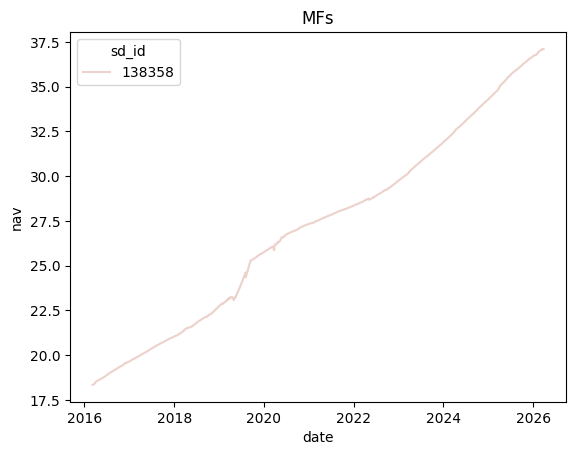

In [45]:
df = conn.execute(
    """
    SELECT sd_id, date, nav
    FROM adjusted_nav
    WHERE sd_id in (
138358
    )
    ORDER BY date
    """
).pl()

fig, ax = plt.subplots()
sns.lineplot(
    df,
    x="date",
    y="nav",
    hue="sd_id",
    ax=ax,
)
ax.set_title('MFs')
ax.set_xlabel('date')
ax.set_ylabel('nav')


SyntaxError: invalid syntax. Perhaps you forgot a comma? (3422226086.py, line 6)

In [ ]:
df = conn.execute(
    """
    SELECT date, sd_id, nav
    FROM amfi.main.nav
    """
).pl()
df = df.pivot(
    values="nav",
    index="date",
    on="sd_id",
    aggregate_function="first"  # since each (date, sd_id) is unique
)


In [7]:
df = conn.execute(
    """
    SELECT distinct sd_id
    FROM amfi.main.nav
    """
).pl()

In [8]:
df

sd_id
i32
115331
115591
116116
116206
106193
100833
106842
110258
100321
